# AutoInsight AI v0.1
## Intelligent Data Understanding Engine

This notebook demonstrates the first phase of AutoInsight AI, an AI-powered framework for automated analysis of engineering datasets.

### Objectives

- Load and inspect raw datasets
- Assess data quality
- Clean missing and inconsistent values
- Generate dataset health reports
- Create engineered features
- Perform exploratory data analysis
- Extract statistical insights

### Dataset

State-wise Power System Dataset containing:

- Region
- State
- Peak Demand
- Peak Demand Met
- Energy Requirement
- Energy Supplied
- Shortage
- Maximum Outage
- Date

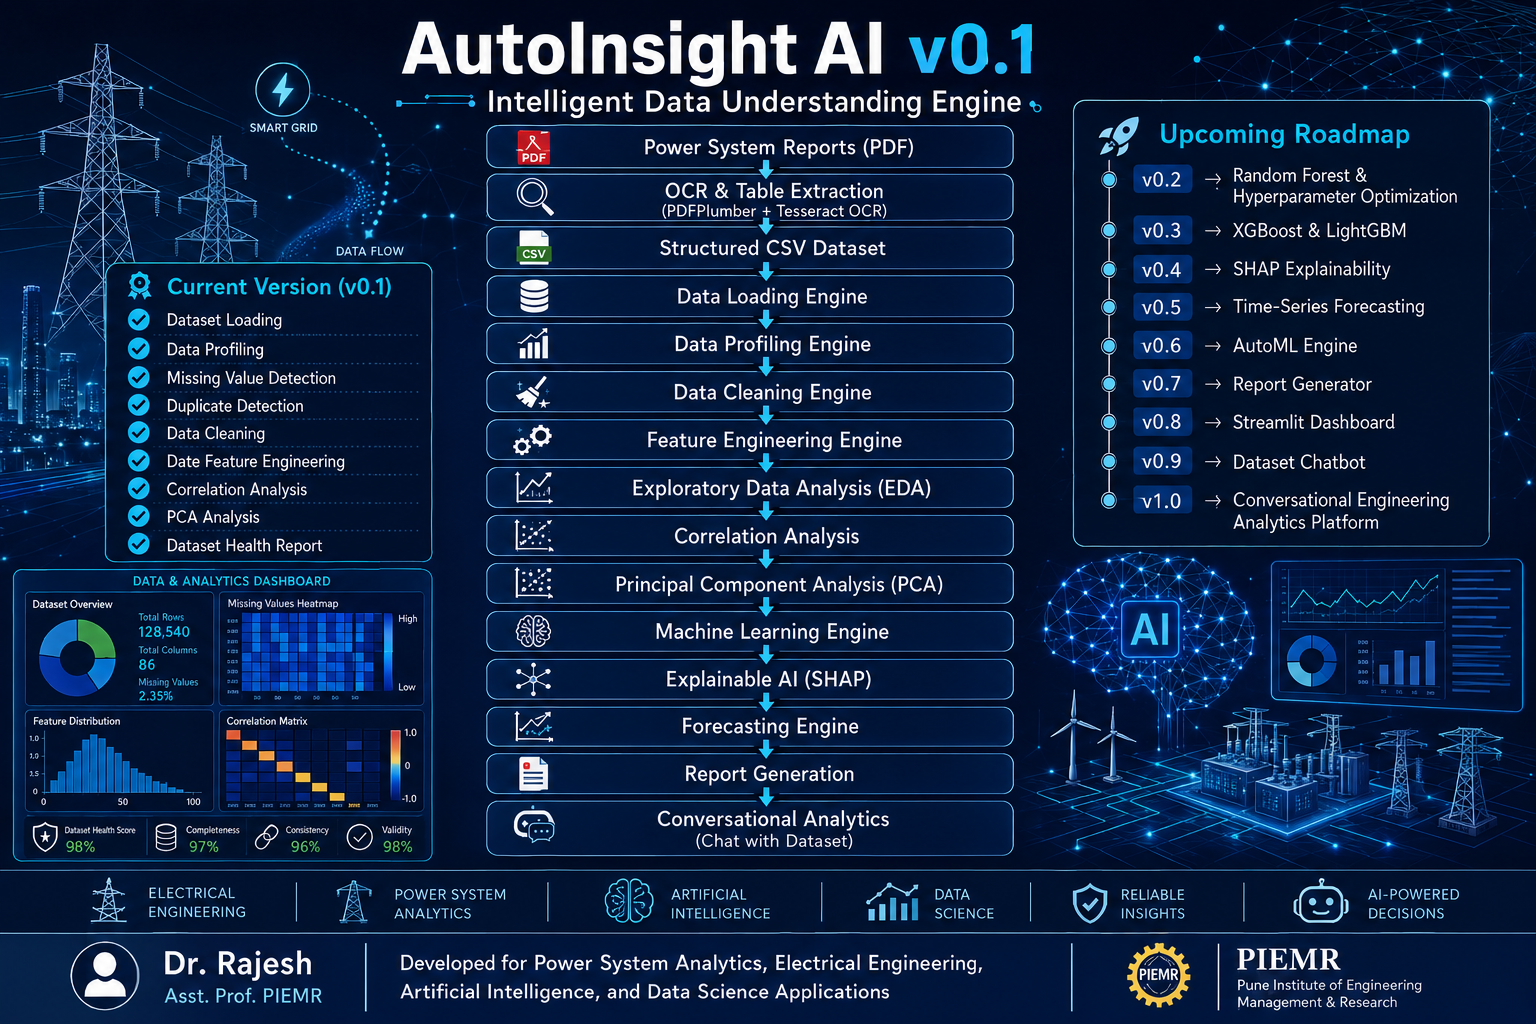

# Import Required Libraries

This section imports all libraries required for data processing, visualization, machine learning, model evaluation, and model persistence.

The libraries are organized according to their functionality to improve readability and maintainability of the code.

---

## Data Manipulation Libraries

### Pandas

Pandas is used for loading, cleaning, transforming, and analyzing structured datasets.

Common applications include:

* Reading CSV and Excel files
* Handling missing values
* Feature engineering
* Data aggregation and filtering

### NumPy

NumPy provides efficient numerical computing capabilities and support for multidimensional arrays.

Common applications include:

* Mathematical operations
* Statistical calculations
* Numerical transformations

---

## Data Visualization Libraries

### Matplotlib

Matplotlib is used for creating visualizations such as:

* Line plots
* Scatter plots
* Histograms
* Bar charts
* Time-series plots

These visualizations help understand trends and patterns within the dataset.

### Seaborn

Seaborn provides advanced statistical visualizations built on top of Matplotlib.

It is particularly useful for:

* Correlation heatmaps
* Distribution plots
* Boxplots
* Pairplots

---

## Warning Management

### Warnings

The warnings library is used to suppress unnecessary warning messages that may clutter notebook outputs.

This improves readability during experimentation and model development.

---

## Data Preprocessing Libraries

### MinMaxScaler

MinMaxScaler scales numerical features into a fixed range, typically between 0 and 1.

Applications:

* Normalization
* Neural Networks
* Distance-based algorithms

### StandardScaler

StandardScaler standardizes features by removing the mean and scaling to unit variance.

Applications:

* Principal Component Analysis (PCA)
* Linear Models
* Support Vector Machines

---

## Dimensionality Reduction

### Principal Component Analysis (PCA)

PCA is used to reduce dataset dimensionality while preserving maximum variance.

Benefits include:

* Feature compression
* Noise reduction
* Data visualization
* Pattern discovery

---

## Dataset Splitting and Validation

### Train-Test Split

The dataset is divided into training and testing subsets to evaluate model performance on unseen data.

### TimeSeriesSplit

TimeSeriesSplit is specifically designed for time-dependent datasets.

Unlike random splitting, it preserves chronological order and prevents data leakage.

### Cross-Validation

Cross-validation evaluates model robustness by repeatedly training and testing on different subsets of the data.

Benefits include:

* Improved reliability
* Reduced overfitting risk
* Better model comparison

---

## Machine Learning Models

### Linear Regression

A baseline regression model that assumes a linear relationship between input variables and the target variable.

### Decision Tree Regressor

A tree-based machine learning algorithm that learns decision rules from data and captures nonlinear relationships.

### Random Forest Regressor

An ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Advantages:

* High predictive performance
* Robustness to noise
* Automatic feature importance estimation

---

## Model Evaluation Metrics

The following metrics are used to evaluate regression model performance.

### Mean Absolute Error (MAE)

Measures the average absolute difference between actual and predicted values.

### Root Mean Squared Error (RMSE)

Measures prediction error while giving higher weight to larger errors.

### Mean Absolute Percentage Error (MAPE)

Measures prediction error as a percentage of actual values.

### R-Squared (R²)

Measures the proportion of variance explained by the model.

Higher R² values indicate better predictive performance.

---

## Model Persistence

### Joblib

Joblib is used to save and load trained machine learning models.

Benefits:

* Faster serialization
* Easy deployment
* Model reuse without retraining

The saved models can later be integrated into AutoInsight AI dashboards, forecasting engines, and conversational analytics systems.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Train/Test
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import joblib

## Step 2: Load Dataset

The dataset is loaded into a Pandas DataFrame.

The parameter:

on_bad_lines="skip"

ensures that malformed rows do not interrupt execution.

## Step 3: Preview Dataset

Display the first few records to understand:

- Column structure
- Data formatting
- Missing values
- Potential inconsistencies

## Step 4: Determine Dataset Size

This step returns:

(Number of Rows, Number of Columns)

which helps estimate the scale of the dataset.

In [2]:
df = pd.read_csv(
    "State_Power_Position_All_Days.csv",
    on_bad_lines="skip"
)

print(df.shape)
df.head()

(58775, 9)


,C.Power Supply Position in States,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Date
0,RegionRegion,States,Max. Demand Met\nduring the day\n(MW),Peak hour\nShortage (MW),Energy\nMet (MU),Drawal\nSchedule (MU),OD(+)/\nUD(-) (MU),Max\nOD (MW),01.01.14
1,NR,Punjab,4792,0,89.5,36.6,1.4,307,01.01.14
2,NaN,Haryana,5354,0,98.2,35.7,1.0,455,01.01.14
3,NaN,Rajasthan,8942,0,183.3,73.6,-1.0,478,01.01.14
4,NaN,Delhi,3711,0,65.2,44.6,0.6,311,01.01.14


## Step 5: Validate Dataset Structure and Assign Standardized Column Names

Before proceeding with data cleaning and analysis, it is important to verify that the dataset contains the expected number of columns.

The State Power Position dataset is expected to contain **9 columns** corresponding to regional, state-level, demand, supply, outage, and date information.

This validation step ensures:

* Dataset integrity
* Correct column mapping
* Prevention of downstream errors
* Improved reproducibility of the analysis

If the dataset contains the expected number of columns, meaningful and standardized column names are assigned. These names improve readability and make subsequent data processing steps easier to understand.

### Expected Columns

1. Region
2. State
3. Peak Demand
4. Peak Demand Met
5. Energy Requirement
6. Energy Supplied
7. Shortage
8. Maximum Outage
9. Date

If the dataset structure does not match the expected format, the program raises an error and stops execution. This prevents accidental analysis of corrupted or incorrectly formatted data.

Finally, the first few records of the dataset are displayed to verify that the column assignment has been performed successfully.


In [3]:
expected_columns = 9

if len(df.columns) == expected_columns:

    df.columns = [
        "Region",
        "State",
        "Peak_Demand",
        "Peak_Met",
        "Energy_Requirement",
        "Energy_Supplied",
        "Shortage",
        "Max_Outage",
        "Date"
    ]

else:

    raise ValueError(
        f"Expected {expected_columns} columns "
        f"but found {len(df.columns)}"
    )

df.head()

,Region,State,Peak_Demand,Peak_Met,Energy_Requirement,Energy_Supplied,Shortage,Max_Outage,Date
0,RegionRegion,States,Max. Demand Met\nduring the day\n(MW),Peak hour\nShortage (MW),Energy\nMet (MU),Drawal\nSchedule (MU),OD(+)/\nUD(-) (MU),Max\nOD (MW),01.01.14
1,NR,Punjab,4792,0,89.5,36.6,1.4,307,01.01.14
2,NaN,Haryana,5354,0,98.2,35.7,1.0,455,01.01.14
3,NaN,Rajasthan,8942,0,183.3,73.6,-1.0,478,01.01.14
4,NaN,Delhi,3711,0,65.2,44.6,0.6,311,01.01.14


## Step 6: Dataset Profiling and Data Quality Assessment

Before performing data cleaning, feature engineering, or machine learning, it is essential to assess the overall quality and structure of the dataset.

This step generates a preliminary dataset profile and identifies potential issues that may affect analysis results.

### Information Collected

#### 1. Dataset Structure

The `info()` function provides:

* Total number of records
* Total number of features
* Data types of each column
* Number of non-null values
* Memory usage

This helps determine whether type conversion or data cleaning is required.

#### 2. Missing Value Analysis

Missing values are counted for every feature to identify incomplete records.

Understanding missing data is important because:

* It can reduce model accuracy
* It may introduce bias
* It often requires imputation or removal

#### 3. Duplicate Record Detection

Duplicate rows are identified and counted.

Duplicate records may occur due to:

* Data entry errors
* Multiple report extractions
* Dataset merging operations

Removing duplicates improves dataset quality and prevents misleading statistical results.

### Objective

The goal of this step is to create a **Dataset Health Report** that provides a clear overview of:

* Dataset completeness
* Dataset consistency
* Data quality issues
* Cleaning requirements

The information obtained here will guide the subsequent preprocessing and feature engineering stages of the AutoInsight AI pipeline.


In [4]:
print(df.info())

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58775 entries, 0 to 58774
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Region              10297 non-null  object
 1   State               58623 non-null  object
 2   Peak_Demand         58069 non-null  object
 3   Peak_Met            58643 non-null  object
 4   Energy_Requirement  58511 non-null  object
 5   Energy_Supplied     58497 non-null  object
 6   Shortage            58555 non-null  object
 7   Max_Outage          58048 non-null  object
 8   Date                57859 non-null  object
dtypes: object(9)
memory usage: 4.0+ MB
None

Missing Values

Region                48478
State                   152
Peak_Demand             706
Peak_Met                132
Energy_Requirement      264
Energy_Supplied         278
Shortage                220
Max_Outage              727
Date                    916
dtype: int64

Duplicate Rows:
3400


## Step 7: Data Cleaning and Missing Value Treatment

Real-world engineering datasets often contain missing values, inconsistent data types, and incomplete records. These issues must be addressed before performing statistical analysis or building machine learning models.

This step performs essential data cleaning operations to improve dataset quality and ensure reliable analytical results.

### 1. Handling Missing Categorical Values

The **Region** column contains categorical information describing the geographical region associated with each state.

Missing region values are filled using the **Forward Fill (ffill)** technique.

This method propagates the last valid observation forward and is appropriate because consecutive records in the dataset often belong to the same region.

### 2. Identifying Numerical Features

The following columns represent quantitative power-system measurements:

* Peak Demand
* Peak Demand Met
* Energy Requirement
* Energy Supplied
* Shortage
* Maximum Outage

These variables are critical for demand analysis, forecasting, and machine learning applications.

### 3. Data Type Conversion

Engineering datasets extracted from reports or spreadsheets may store numerical values as text strings.

The `pd.to_numeric()` function converts each numerical feature into an appropriate numeric data type.

The parameter:

```python
errors="coerce"
```

ensures that invalid or non-numeric entries are automatically converted into missing values (`NaN`) for later treatment.

### 4. Missing Value Imputation

Missing numerical values are replaced using the **Median Imputation** technique.

Median imputation is preferred because:

* It is robust to outliers.
* It preserves the central tendency of the data.
* It performs better than mean imputation when the distribution is skewed.

### Objective

The goal of this preprocessing stage is to produce a clean and consistent dataset suitable for:

* Exploratory Data Analysis (EDA)
* Statistical Analysis
* Dimensionality Reduction (PCA)
* Machine Learning Model Development
* Explainable AI Analysis

This step forms a critical component of the **AutoInsight AI Data Cleaning Engine**.


In [4]:
df["Region"] = df["Region"].ffill()

numeric_columns = [
    "Peak_Demand",
    "Peak_Met",
    "Energy_Requirement",
    "Energy_Supplied",
    "Shortage",
    "Max_Outage"
]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df[numeric_columns] = df[
    numeric_columns
].fillna(
    df[numeric_columns].median()
)

## Step 8: Date Processing and Temporal Feature Engineering

Time is one of the most important factors influencing power demand, energy consumption, and grid operations. To capture temporal patterns and seasonal trends, the date information must be converted into a machine-readable format.

This step transforms the raw date column into a structured datetime format and extracts several useful time-based features.

### 1. Date Conversion

The **Date** column is converted into a datetime object using:

```python
pd.to_datetime()
```

This enables Python to recognize dates and perform time-based operations.

The parameter:

```python
errors="coerce"
```

ensures that invalid date values are automatically converted into missing values (`NaT`) rather than causing execution errors.

### 2. Year Extraction

The **Year** feature captures long-term demand patterns and annual trends.

Examples:

* Economic growth effects
* Infrastructure expansion
* Population growth
* Renewable energy penetration

### 3. Month Extraction

The **Month** feature helps identify seasonal variations in electricity demand.

Examples:

* Summer cooling loads
* Winter heating loads
* Agricultural pumping seasons
* Industrial production cycles

### 4. Day Extraction

The **Day** feature captures short-term fluctuations and daily operational patterns.

It can help identify:

* Demand spikes
* Holiday effects
* Reporting irregularities

### 5. Quarter Extraction

The **Quarter** feature groups months into business and operational quarters.

Examples:

* Q1 (Jan–Mar)
* Q2 (Apr–Jun)
* Q3 (Jul–Sep)
* Q4 (Oct–Dec)

Quarterly analysis is frequently used in:

* Utility planning
* Energy forecasting
* Regulatory reporting
* Financial assessments

### Why Feature Engineering Matters

Machine learning algorithms cannot directly understand calendar dates. By extracting meaningful temporal attributes, the model can learn hidden patterns associated with seasonality, long-term growth, and operational cycles.

These engineered features often improve:

* Predictive accuracy
* Trend analysis
* Demand forecasting
* Explainability

### Objective

The goal of this step is to transform raw date information into informative temporal features that can be utilized by:

* Exploratory Data Analysis (EDA)
* Statistical Analysis
* Machine Learning Models
* Time-Series Forecasting Systems

This forms a key component of the **AutoInsight AI Feature Engineering Engine**.


In [5]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df["Quarter"] = df["Date"].dt.quarter

df.head()

,Region,State,Peak_Demand,Peak_Met,Energy_Requirement,Energy_Supplied,Shortage,Max_Outage,Date,Year,Month,Day,Quarter
0,RegionRegion,States,1943.0,0.0,39.7,16.8,0.1,170.0,2014-01-01,2014.0,1.0,1.0,1.0
1,NR,Punjab,4792.0,0.0,89.5,36.6,1.4,307.0,2014-01-01,2014.0,1.0,1.0,1.0
2,NR,Haryana,5354.0,0.0,98.2,35.7,1.0,455.0,2014-01-01,2014.0,1.0,1.0,1.0
3,NR,Rajasthan,8942.0,0.0,183.3,73.6,-1.0,478.0,2014-01-01,2014.0,1.0,1.0,1.0
4,NR,Delhi,3711.0,0.0,65.2,44.6,0.6,311.0,2014-01-01,2014.0,1.0,1.0,1.0


In [7]:
df = df.sort_values(
    by="Date"
)

df.reset_index(
    drop=True,
    inplace=True
)

## Step 9: Chronological Sorting of Time-Series Data

For power-system analysis and forecasting, maintaining the correct chronological order of observations is essential.

Many datasets obtained from reports, merged files, or data extraction processes may not be arranged in time sequence. Before performing trend analysis, forecasting, or time-series cross-validation, the dataset must be sorted according to the date of observation.

### 1. Sort Records by Date

The dataset is sorted in ascending order using the **Date** column.

This ensures that:

* Older observations appear first.
* Recent observations appear later.
* Temporal relationships are preserved.

Maintaining chronological order is critical for:

* Time-Series Analysis
* Demand Trend Analysis
* Forecasting Models
* TimeSeriesSplit Validation
* Lag Feature Generation

### 2. Reset Dataset Index

After sorting, the original row indices may become disordered.

The index is therefore reset to create a clean sequential numbering of records.

Using:

```python
drop=True
```

prevents the old index from being added as a separate column.

### Why This Step Is Important

Unlike traditional machine learning datasets, time-series datasets contain temporal dependencies.

If records are not arranged chronologically:

* Trends may be distorted.
* Forecasting models may learn incorrect patterns.
* Data leakage may occur during model evaluation.

Proper sorting ensures that future observations never appear before past observations.

### Objective

The objective of this step is to prepare the dataset for:

* Time-Series Exploratory Data Analysis
* Trend Visualization
* Lag Feature Creation
* Forecasting Models
* TimeSeries Cross-Validation

This forms an important component of the **AutoInsight AI Time-Series Processing Engine**.


## Step 9.1: Identify Potential Outliers in Peak Demand

After calculating the Interquartile Range (IQR) and establishing the lower and upper bounds, the next step is to identify observations that fall outside the acceptable range.

An observation is classified as a potential outlier if:

* Peak Demand is less than the lower bound, or
* Peak Demand is greater than the upper bound.

These observations may represent:

* Abnormal demand conditions
* Extreme operating scenarios
* Data entry errors
* Measurement anomalies

The identified outliers are stored in a separate DataFrame for further inspection.

Finally, the total number of detected outliers is displayed to assess the extent of unusual observations present in the dataset.

### Objective

The objective of this step is to quantify the number of extreme Peak Demand observations before deciding whether they should be:

* Investigated
* Retained
* Transformed
* Removed

This information supports data quality assessment and improves the reliability of subsequent machine learning models.


In [8]:
Q1 = df["Peak_Demand"].quantile(0.25)

Q3 = df["Peak_Demand"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Peak_Demand"] < lower)
    |
    (df["Peak_Demand"] > upper)
]

print("Outliers Found:", len(outliers))

Outliers Found: 1459


In [9]:
df.isnull().sum()

Region                  0
State                 152
Peak_Demand             0
Peak_Met                0
Energy_Requirement      0
Energy_Supplied         0
Shortage                0
Max_Outage              0
Date                  916
Year                  916
Month                 916
Day                   916
Quarter               916
dtype: int64

In [10]:
df = df[
    (df["Peak_Demand"] >= lower)
    &
    (df["Peak_Demand"] <= upper)
]

print(df.shape)

(57316, 13)


## Step 10: Advanced Feature Engineering for Time-Series Analysis

Feature engineering is the process of creating new variables that help machine learning models better understand patterns within the data.

In power-system analytics, historical demand patterns often contain valuable information about future demand behavior. Therefore, additional time-series features are created to capture temporal dependencies and trends.

### 1. Demand Normalization

The **Peak Demand** feature is normalized using the Min-Max Scaling technique.

Min-Max Scaling transforms values into a fixed range between 0 and 1.

Benefits include:

* Improved numerical stability
* Easier comparison between observations
* Better visualization
* Support for future machine learning algorithms

The transformed feature is stored as:

```text
Demand_Normalized
```

### 2. Lag Feature Creation

Lag features allow the model to learn from historical observations.

A lag feature represents the value of a variable at a previous time step.

#### Demand_Lag1

Stores the Peak Demand from the previous observation.

```text
Today's Demand
       ↓
Yesterday's Demand
```

This helps the model capture short-term demand persistence.

#### Demand_Lag7

Stores the Peak Demand from seven observations earlier.

```text
Today's Demand
       ↓
Demand 7 Days Ago
```

This helps identify weekly demand patterns and recurring trends.

### Why Lag Features Matter

Electricity demand typically exhibits temporal dependence.

Examples:

* Today's demand is often related to yesterday's demand.
* Weekly demand patterns tend to repeat.
* Seasonal effects influence future consumption.

Lag features enable machine learning models to capture these relationships.

### 3. Rolling Mean Feature

A rolling mean calculates the average demand over a moving window.

The following feature is created:

```text
Rolling_Mean_7
```

which represents the average Peak Demand over the previous seven observations.

Benefits:

* Smooths short-term fluctuations
* Reduces noise
* Highlights underlying demand trends
* Improves forecasting capability

Example:

```text
Day 1 → 1200
Day 2 → 1250
Day 3 → 1180
Day 4 → 1300
Day 5 → 1270
Day 6 → 1240
Day 7 → 1290

Rolling Mean = Average of these values
```

### 4. Handling Missing Values Generated by Feature Engineering

Lag and rolling calculations naturally create missing values at the beginning of the dataset because previous observations are unavailable.

For example:

* Demand_Lag1 produces one missing value.
* Demand_Lag7 produces seven missing values.
* Rolling_Mean_7 produces six missing values.

These incomplete records are removed using:

```python
df.dropna()
```

to ensure that all engineered features contain valid information.

### Objective

The objective of this step is to create informative time-series features that improve:

* Trend analysis
* Demand forecasting
* Machine learning performance
* Explainable AI insights

These engineered features form a key component of the **AutoInsight AI Feature Engineering Engine** and will later be utilized by Random Forest, XGBoost, SHAP, and forecasting models.


In [11]:
df["Demand_Normalized"] = MinMaxScaler().fit_transform(
    df[["Peak_Demand"]]
)

# Lag Features

df["Demand_Lag1"] = df["Peak_Demand"].shift(1)

df["Demand_Lag7"] = df["Peak_Demand"].shift(7)

# Rolling Mean

df["Rolling_Mean_7"] = (
    df["Peak_Demand"]
    .rolling(7)
    .mean()
)

df = df.dropna()

## Step 12: Correlation Analysis Using a Heatmap

Correlation analysis is performed to understand the strength and direction of relationships between numerical variables in the dataset.

In power-system analytics, identifying highly correlated variables helps reveal important dependencies between demand, supply, shortages, outages, and engineered features.

### 1. Selection of Numerical Features

Only numerical columns are selected for correlation analysis because correlation coefficients can only be computed between quantitative variables.

Examples include:

* Peak Demand
* Peak Demand Met
* Energy Requirement
* Energy Supplied
* Shortage
* Maximum Outage
* Year
* Month
* Lag Features
* Rolling Statistics

### 2. Correlation Matrix Computation

The correlation matrix measures the relationship between every pair of numerical variables.

Correlation values range from:

where:

| Correlation Value | Interpretation                |
| ----------------- | ----------------------------- |
| +1                | Perfect Positive Relationship |
| 0                 | No Relationship               |
| -1                | Perfect Negative Relationship |

### Interpretation

#### Strong Positive Correlation

```text
+0.70 to +1.00
```

As one variable increases, the other tends to increase.

Example:

```text
Energy Requirement ↑
Peak Demand ↑
```

#### Strong Negative Correlation

```text
-0.70 to -1.00
```

As one variable increases, the other tends to decrease.

Example:

```text
Outages ↑
Energy Supplied ↓
```

#### Weak Correlation

```text
Near 0
```

Little or no linear relationship exists between the variables.

### 3. Correlation Heatmap Visualization

A heatmap is generated to visually represent the correlation matrix.

Features of the heatmap:

* Color-coded relationships
* Numerical correlation coefficients
* Easy identification of strong dependencies
* Quick detection of redundant features

Color Interpretation:

🔴 Red → Strong Positive Correlation

🔵 Blue → Strong Negative Correlation

⚪ Light Colors → Weak Correlation

### Why Correlation Analysis Matters

Correlation analysis helps:

* Identify influential variables
* Detect multicollinearity
* Support feature selection
* Improve model interpretability
* Generate engineering insights

For example, if Energy Requirement shows a strong positive correlation with Peak Demand, it may become an important predictor in machine learning models.

### Objective

The objective of this step is to explore relationships among power-system variables and identify the factors most strongly associated with electricity demand.

This forms a key component of the **AutoInsight AI Exploratory Data Analysis (EDA) Engine** and provides valuable insights for subsequent machine learning and Explainable AI stages.


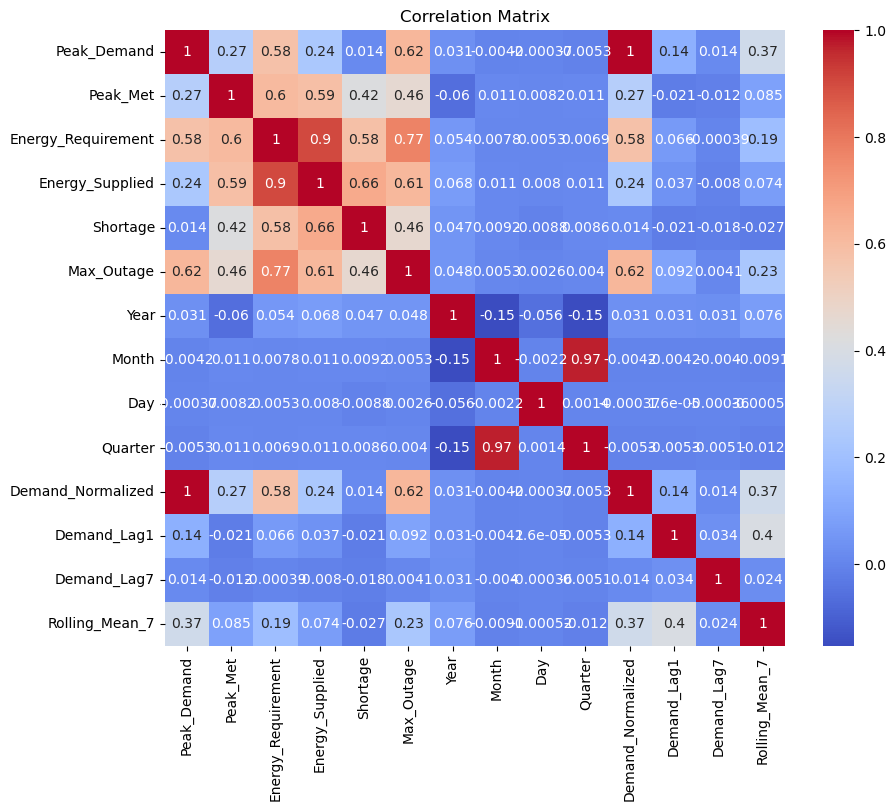

In [11]:
corr = df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Step 13: Principal Component Analysis (PCA) and Scree Plot

Engineering datasets often contain multiple variables that are highly correlated with one another. Such redundancy can increase computational complexity and make it difficult to identify the most informative patterns in the data.

To address this issue, **Principal Component Analysis (PCA)** is performed.

PCA is a dimensionality reduction technique that transforms correlated variables into a smaller set of uncorrelated variables called **Principal Components** while retaining most of the information present in the original dataset.

### Features Selected for PCA

The following power-system variables are used:

* Peak Demand
* Peak Demand Met
* Energy Requirement
* Energy Supplied

These variables represent the core demand-supply characteristics of the electrical power system.

### 1. Feature Standardization

Before applying PCA, all features are standardized using:

```python
StandardScaler()
```

Standardization transforms each feature to have:

* Mean = 0
* Standard Deviation = 1

This step is essential because PCA is sensitive to the scale of the variables.

Without scaling, variables with larger numerical values may dominate the principal components.

### 2. Principal Component Analysis

PCA identifies new orthogonal axes that maximize the variance captured from the original dataset.

The first principal component captures the largest amount of variance.

The second principal component captures the next largest amount of variance while remaining independent of the first.

This process continues for all remaining components.

### Variance Preservation

The objective of PCA is to retain as much information as possible using fewer dimensions.

The variance captured by each component is measured using the **Explained Variance Ratio**.

### 3. Scree Plot Generation

A Scree Plot is created to visualize how much variance is explained by each principal component.

The plot helps determine:

* The importance of each component
* The optimal number of components to retain
* The point where additional components contribute little new information

### Interpretation of the Scree Plot

A steep decline in explained variance indicates that most information is concentrated in the first few components.

An "elbow" in the curve often suggests the ideal number of components to retain.

Example:

```text
PC1 → 65% Variance

PC2 → 22% Variance

PC3 → 9% Variance

PC4 → 4% Variance
```

In this case:

```text
PC1 + PC2 = 87% Variance
```

meaning two components may adequately represent the dataset.

### Why PCA is Important

PCA provides several benefits:

* Reduces dimensionality
* Removes redundancy
* Improves visualization
* Reduces computational cost
* Supports feature selection
* Reveals hidden patterns

In power-system analytics, PCA can help identify the dominant factors influencing demand and supply behavior across different states and regions.

### Objective

The objective of this step is to analyze the variance structure of the dataset and determine whether the original features can be represented using a smaller number of informative components.

This forms an important part of the **AutoInsight AI Exploratory Data Analysis (EDA) Engine** and supports future machine learning and forecasting modules.


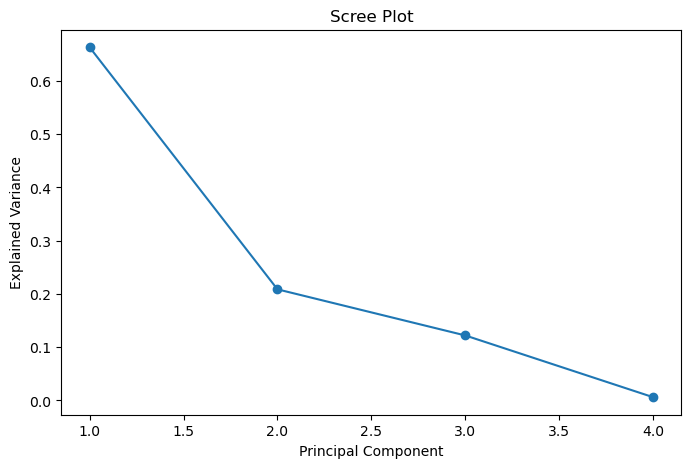

In [12]:
features = [
    "Peak_Demand",
    "Peak_Met",
    "Energy_Requirement",
    "Energy_Supplied"
]

scaled_features = StandardScaler().fit_transform(
    df[features]
)

pca = PCA()

pca.fit(scaled_features)

explained_variance = (
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    range(
        1,
        len(explained_variance)+1
    ),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")

plt.show()

## Step 14: Time-Series Visualization of Peak Demand

Understanding how electricity demand changes over time is one of the primary objectives of power-system analytics.

A time-series plot is created to visualize the variation of **Peak Demand** across different dates and identify long-term trends, seasonal patterns, and unusual demand fluctuations.

### What is a Time-Series Plot?

A time-series plot displays observations in chronological order.

In this visualization:

* The **X-axis** represents time (Date).
* The **Y-axis** represents Peak Demand.

Each point on the graph corresponds to the peak electricity demand recorded on a specific date.

### Why Visualize Demand Over Time?

Time-series visualization helps answer important questions such as:

* Is electricity demand increasing over the years?
* Are there seasonal demand patterns?
* Are there sudden spikes or drops in demand?
* Are there abnormal events affecting power consumption?
* Is the dataset suitable for forecasting?

### Insights That Can Be Obtained

#### Trend Analysis

A consistent upward movement may indicate:

* Economic growth
* Population growth
* Industrial expansion
* Increased electrification

A downward movement may indicate:

* Reduced consumption
* Energy efficiency improvements
* Economic slowdown

#### Seasonal Patterns

Recurring peaks may indicate:

* Summer cooling loads
* Winter heating demand
* Agricultural irrigation cycles
* Festival-related consumption

#### Anomaly Detection

Sharp spikes or drops may indicate:

* Extreme weather events
* Grid disturbances
* Data quality issues
* Exceptional demand conditions

### Importance for Machine Learning

Time-series visualization provides a preliminary understanding of the temporal behavior of demand before developing:

* Regression Models
* Forecasting Models
* AutoML Pipelines
* Explainable AI Systems

It also helps validate the effectiveness of the lag and rolling-window features created during feature engineering.

### Objective

The objective of this step is to visually explore the temporal evolution of electricity demand and identify meaningful patterns that may influence future predictive modeling and forecasting tasks.

This visualization forms a core component of the **AutoInsight AI Exploratory Data Analysis (EDA) Engine**.


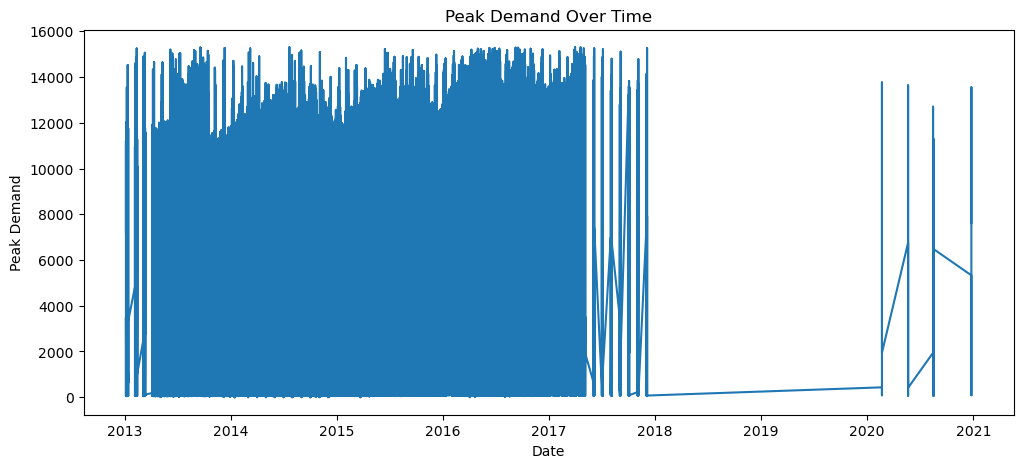

In [13]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Peak_Demand"]
)

plt.title("Peak Demand Over Time")

plt.xlabel("Date")
plt.ylabel("Peak Demand")

plt.show()

## Step 15: State-Wise Average Peak Demand Analysis

Electricity demand varies significantly across states due to differences in:

* Population
* Industrial activity
* Urbanization
* Economic development
* Agricultural consumption
* Climatic conditions

To understand these regional variations, the average Peak Demand is calculated for each state and visualized using a bar chart.

### 1. State-Level Aggregation

The dataset is grouped according to the **State** column.

For each state, the mean value of **Peak Demand** is calculated.

This provides a representative measure of the typical electricity demand observed within that state over the study period.

### Why Use the Mean?

The average Peak Demand helps:

* Compare electricity consumption across states
* Identify high-demand regions
* Support power-system planning
* Understand regional energy requirements

### 2. Sorting States by Demand

The states are sorted in descending order of average Peak Demand.

This makes it easier to identify:

* Highest-demand states
* Moderate-demand states
* Low-demand states

and provides a clearer visual comparison.

### 3. Bar Chart Visualization

A bar chart is generated to compare average Peak Demand across all states.

In the chart:

* Each bar represents a state.
* Bar height represents the average Peak Demand.
* Taller bars indicate higher electricity demand.

### Insights That Can Be Obtained

#### High-Demand States

States with the largest average demand may indicate:

* Large populations
* Heavy industrial activity
* Major urban centers
* High economic output

#### Moderate-Demand States

These states may represent balanced consumption patterns with moderate industrial and residential loads.

#### Low-Demand States

States with lower demand may have:

* Smaller populations
* Limited industrialization
* Lower electricity consumption

### Importance for Power-System Planning

State-wise demand analysis is useful for:

* Grid expansion planning
* Resource allocation
* Transmission network design
* Renewable energy integration
* Regional demand forecasting

### Importance for Machine Learning

Understanding state-level demand behavior helps:

* Identify regional demand patterns
* Support feature engineering
* Generate business insights
* Improve Explainable AI interpretations

### Objective

The objective of this step is to compare electricity demand across states and identify the regions that contribute most significantly to overall power consumption.

This analysis forms an important component of the **AutoInsight AI Statistical Insights Engine** and helps generate automated regional demand insights.


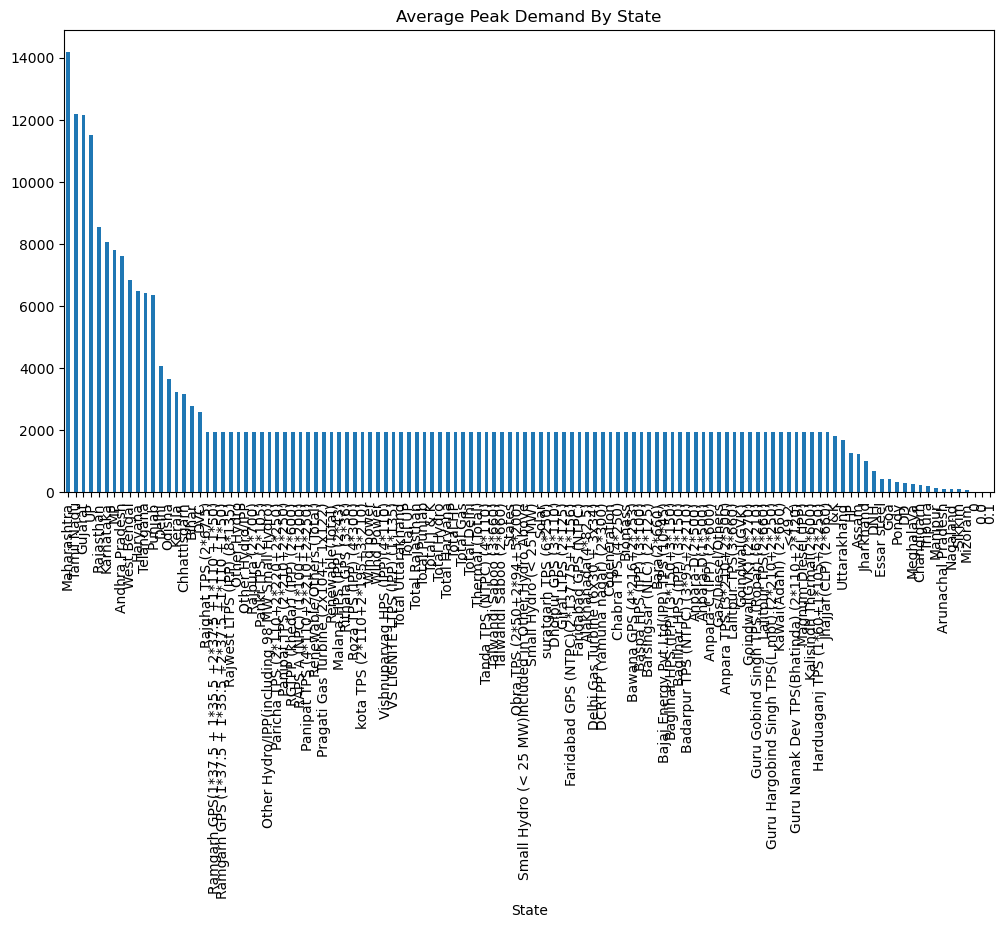

In [14]:
state_demand = (
    df.groupby("State")
    ["Peak_Demand"]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(12,6))

state_demand.plot(
    kind="bar"
)

plt.title(
    "Average Peak Demand By State"
)

plt.show()

In [15]:
df.to_csv(
    "cleaned_power_dataset.csv",
    index=False
)